## Hierarchical clustering

- an unsupervised ML algorithm used to group similar data points into clusters

- builds a tree-like structure (dendrogram) that represents the nested grouping of data points

- 2 main types of hierarchical clustering:
1. Agglomerative:
- This method starts with individual data points and merges them into larger clusters.

2. Divisive:
- This method starts with one large cluster and divides it into smaller clusters.

While merging 2 clusters we check the distance between 2 every pair of clusters and merge the pair with the **least distance**/most similarity

Ways of defining Inter Cluster distance/similarity. Some of them are:

1. Min Distance: Find the minimum distance between any 2 points of the cluster.

2. Max Distance: Find the maximum distance between any 2 points of the cluster.

3. Group Average: Find the average distance between every 2 points of the clusters.

4. Ward's Method: The similarity of 2 clusters is based on the increase in squared error when 2 clusters are merged.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6],
    'Age': [25, 26, 60, 62, 22, 65],
    'SpendingScore': [80, 85, 15, 10, 88, 20]
}

df = pd.DataFrame(data)
print("---Original Data---")
df

---Original Data---


,CustomerID,Age,SpendingScore
0,1,25,80
1,2,26,85
2,3,60,15
3,4,62,10
4,5,22,88
5,6,65,20


In [3]:
x = df[['Age', 'SpendingScore']]

hc_model = AgglomerativeClustering(
    n_clusters= 2,
    metric= 'euclidean',
    linkage= 'ward'
)

clusters = hc_model.fit_predict(x)
df['H Clusters'] = clusters

df

,CustomerID,Age,SpendingScore,H Clusters
0,1,25,80,1
1,2,26,85,1
2,3,60,15,0
3,4,62,10,0
4,5,22,88,1
5,6,65,20,0


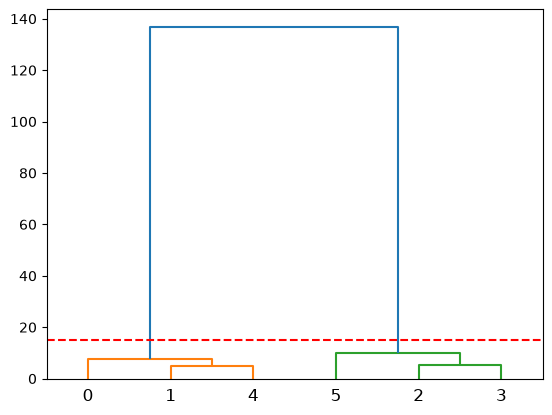

In [10]:
z = linkage(x, method= 'ward')
dendrogram(z)

plt.axhline(y= 15, c= 'r', linestyle= '--')
plt.show()

- Divisive clustering you won't really find in Sci-Kit Learn because it is computationally intensive
- you have a large cluster of a big dataset, figuring out every possible way of splitting that data is tough for the computer
- 